In [1]:
from pathlib import Path
from time import perf_counter
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

DATA_DIR = Path(r"P:\HACKATHONS\SIH26PS67\DATA\REF")
COASTLINE_DIR = DATA_DIR / "coastline"
GSHHG_DIR = COASTLINE_DIR / "gshhg"   # notice the G at the end

GSHHS_DIR = GSHHG_DIR / "GSHHS_shp"   # notice the S at the end
WDBII_DIR = GSHHG_DIR / "WDBII_shp"

RESOLUTIONS = ["c", "l", "i", "h", "f"]

In [2]:
RESOLUTION_INFO = {
    "f": {
        "name": "Full",
        "description": "Maximum resolution; original data has not been decimated."
    },
    "h": {
        "name": "High",
        "description": "Reduced from full resolution."
    },
    "i": {
        "name": "Intermediate",
        "description": "Reduced from high resolution."
    },
    "l": {
        "name": "Low",
        "description": "Reduced from intermediate resolution."
    },
    "c": {
        "name": "Crude",
        "description": "Reduced from low resolution."
    },
}

RESOLUTION_ORDER = ["f", "h", "i", "l", "c"]

In [3]:
def count_ring_vertices(ring):
    return len(ring.coords)


def count_polygon_vertices(polygon):
    count = count_ring_vertices(polygon.exterior)

    for interior in polygon.interiors:
        count += count_ring_vertices(interior)

    return count


def count_geometry_vertices(geometry):
    if geometry is None or geometry.is_empty:
        return 0

    geometry_type = geometry.geom_type

    if geometry_type == "Polygon":
        return count_polygon_vertices(geometry)

    if geometry_type == "MultiPolygon":
        return sum(
            count_polygon_vertices(polygon)
            for polygon in geometry.geoms
        )

    if hasattr(geometry, "geoms"):
        return sum(
            count_geometry_vertices(part)
            for part in geometry.geoms
        )

    if hasattr(geometry, "coords"):
        return len(geometry.coords)

    return 0

In [4]:
def count_polygon_parts(geometry):
    if geometry is None or geometry.is_empty:
        return 0

    if geometry.geom_type == "Polygon":
        return 1

    if geometry.geom_type == "MultiPolygon":
        return len(geometry.geoms)

    if hasattr(geometry, "geoms"):
        return sum(
            count_polygon_parts(part)
            for part in geometry.geoms
        )

    return 0

In [5]:
def count_polygon_holes(polygon):
    return len(polygon.interiors)


def count_geometry_holes(geometry):
    if geometry is None or geometry.is_empty:
        return 0

    if geometry.geom_type == "Polygon":
        return count_polygon_holes(geometry)

    if geometry.geom_type == "MultiPolygon":
        return sum(
            count_polygon_holes(polygon)
            for polygon in geometry.geoms
        )

    if hasattr(geometry, "geoms"):
        return sum(
            count_geometry_holes(part)
            for part in geometry.geoms
        )

    return 0

In [6]:
def load_resolution(resolution, level=1):
    path = (
        GSHHS_DIR
        / resolution
        / f"GSHHS_{resolution}_L{level}.shp"
    )

    if not path.exists():
        raise FileNotFoundError(path)

    start = perf_counter()

    data = gpd.read_file(path)

    elapsed = perf_counter() - start

    print(f"Loaded: {resolution.upper()} / L{level}")
    print(f"Path: {path}")
    print(f"Features: {len(data):,}")
    print(f"Load time: {elapsed:.2f} seconds")

    return data

In [7]:
gdf_f = load_resolution("f", level=1)

gdf_f.head()

Loaded: F / L1
Path: P:\HACKATHONS\SIH26PS67\DATA\REF\coastline\gshhg\GSHHS_shp\f\GSHHS_f_L1.shp
Features: 179,837
Load time: 1.65 seconds


,id,level,source,parent_id,sibling_id,area,geometry
0,0-E,1,WVS,-1,-1,5.065405e+07,"POLYGON ((180 68.99378, 180 65.03378, 179.9983..."
1,0-W,1,WVS,-1,-1,5.065405e+07,"POLYGON ((-180 68.99378, -179.99844 68.99292, ..."
2,1,1,WVS,-1,-1,2.922097e+07,"POLYGON ((32.28292 31.2325, 32.2845 31.23281, ..."
3,2,1,WVS,-1,-1,2.015474e+07,"POLYGON ((-79.92628 9.31236, -79.92538 9.3124,..."
4,3,1,WVS,-1,-1,1.753416e+07,"POLYGON ((-73.36172 -53.00042, -73.36261 -53, ..."


In [8]:
print("CRS:")
print(gdf_f.crs)

print("\nColumns:")
print(gdf_f.columns.tolist())

print("\nGeometry types:")
print(gdf_f.geometry.geom_type.value_counts())

CRS:
EPSG:4326

Columns:
['id', 'level', 'source', 'parent_id', 'sibling_id', 'area', 'geometry']

Geometry types:
Polygon    179837
Name: count, dtype: int64


In [9]:
def analyze_resolution(resolution, level=1):
    path = (
        GSHHS_DIR
        / resolution
        / f"GSHHS_{resolution}_L{level}.shp"
    )

    start = perf_counter()

    data = gpd.read_file(path)

    load_time = perf_counter() - start

    # Geometry statistics
    data["vertex_count"] = data.geometry.apply(
        count_geometry_vertices
    )

    data["polygon_parts"] = data.geometry.apply(
        count_polygon_parts
    )

    data["hole_count"] = data.geometry.apply(
        count_geometry_holes
    )

    # WKB size
    data["wkb_size"] = data.geometry.apply(
        lambda geom: (
            len(geom.wkb)
            if geom is not None and not geom.is_empty
            else 0
        )
    )

    # Geometry validity
    valid_count = data.geometry.is_valid.sum()
    empty_count = data.geometry.is_empty.sum()
    null_count = data.geometry.isna().sum()

    # File sizes
    extensions = [".shp", ".shx", ".dbf", ".prj"]

    component_sizes = {}

    for extension in extensions:
        component_path = path.with_suffix(extension)

        if component_path.exists():
            component_sizes[extension] = component_path.stat().st_size
        else:
            component_sizes[extension] = 0

    total_file_size = sum(component_sizes.values())

    result = {
        "resolution": resolution,
        "resolution_name": RESOLUTION_INFO[resolution]["name"],

        "features": len(data),

        "total_vertices": data["vertex_count"].sum(),
        "mean_vertices": data["vertex_count"].mean(),
        "median_vertices": data["vertex_count"].median(),
        "p95_vertices": data["vertex_count"].quantile(0.95),
        "p99_vertices": data["vertex_count"].quantile(0.99),
        "max_vertices": data["vertex_count"].max(),

        "total_polygon_parts": data["polygon_parts"].sum(),
        "total_holes": data["hole_count"].sum(),

        "total_wkb_bytes": data["wkb_size"].sum(),
        "mean_wkb_bytes": data["wkb_size"].mean(),

        "valid_geometries": valid_count,
        "empty_geometries": empty_count,
        "null_geometries": null_count,

        "shp_bytes": component_sizes[".shp"],
        "shx_bytes": component_sizes[".shx"],
        "dbf_bytes": component_sizes[".dbf"],
        "prj_bytes": component_sizes[".prj"],

        "total_file_bytes": total_file_size,
        "load_time_seconds": load_time,

        "data": data,
    }

    return result

In [10]:
resolution_results = {}

for resolution in RESOLUTION_ORDER:
    print("=" * 60)

    resolution_results[resolution] = analyze_resolution(
        resolution,
        level=1
    )

In [11]:
resolution_summary = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key != "data"
    }
    for result in resolution_results.values()
])

resolution_summary

,resolution,resolution_name,features,total_vertices,mean_vertices,median_vertices,p95_vertices,p99_vertices,max_vertices,total_polygon_parts,...,mean_wkb_bytes,valid_geometries,empty_geometries,null_geometries,shp_bytes,shx_bytes,dbf_bytes,prj_bytes,total_file_bytes,load_time_seconds
0,f,Full,179837,9453089,52.564761,10.0,69.00,324.00,1160926,179837,...,854.036183,179836,0,0,161320396,1438796,38125670,143,200885005,1.800290
1,h,High,144749,1626467,11.236465,4.0,14.00,56.00,139786,144749,...,192.783432,144748,0,0,34129516,1158092,30687014,143,65974765,1.173266
2,i,Intermediate,32830,340359,10.367316,4.0,13.00,47.00,34332,32830,...,178.877064,32829,0,0,7284324,262740,6960186,143,14507393,0.276576
3,l,Low,5706,56351,9.875745,4.0,12.00,55.00,6733,5706,...,171.011917,5706,0,0,1221252,45748,1209898,143,2477041,0.048504
4,c,Crude,742,7282,9.814016,4.0,15.95,85.62,1004,742,...,170.024259,742,0,0,158164,6036,157530,143,321873,0.007874


In [12]:
important_columns = [
    "resolution",
    "resolution_name",
    "features",
    "total_vertices",
    "mean_vertices",
    "median_vertices",
    "p95_vertices",
    "p99_vertices",
    "max_vertices",
    "total_polygon_parts",
    "total_holes",
    "total_wkb_bytes",
    "total_file_bytes",
]

resolution_summary[important_columns]

,resolution,resolution_name,features,total_vertices,mean_vertices,median_vertices,p95_vertices,p99_vertices,max_vertices,total_polygon_parts,total_holes,total_wkb_bytes,total_file_bytes
0,f,Full,179837,9453089,52.564761,10.0,69.00,324.00,1160926,179837,0,153587305,200885005
1,h,High,144749,1626467,11.236465,4.0,14.00,56.00,139786,144749,0,27905209,65974765
2,i,Intermediate,32830,340359,10.367316,4.0,13.00,47.00,34332,32830,0,5872534,14507393
3,l,Low,5706,56351,9.875745,4.0,12.00,55.00,6733,5706,0,975794,2477041
4,c,Crude,742,7282,9.814016,4.0,15.95,85.62,1004,742,0,126158,321873


In [13]:
feature_counts = resolution_summary[
    ["resolution", "resolution_name", "features"]
]

feature_counts

,resolution,resolution_name,features
0,f,Full,179837
1,h,High,144749
2,i,Intermediate,32830
3,l,Low,5706
4,c,Crude,742


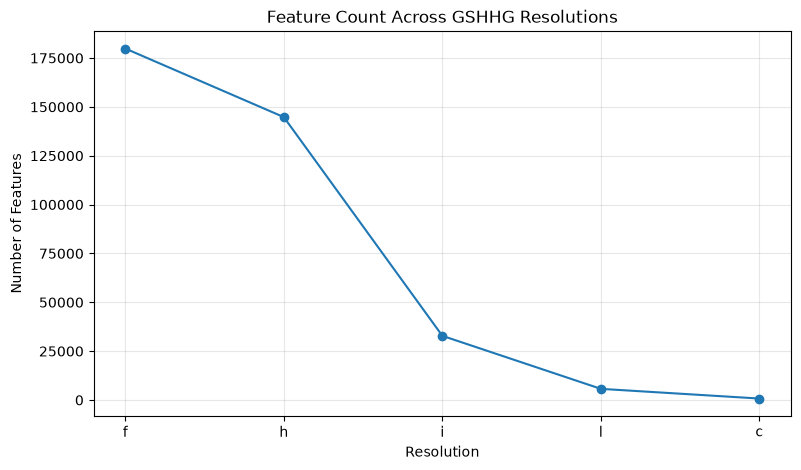

In [14]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["features"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Number of Features")
plt.title("Feature Count Across GSHHG Resolutions")

plt.grid(True, alpha=0.3)
plt.show()

In [15]:
resolution_summary[
    [
        "resolution",
        "resolution_name",
        "total_vertices"
    ]
]

,resolution,resolution_name,total_vertices
0,f,Full,9453089
1,h,High,1626467
2,i,Intermediate,340359
3,l,Low,56351
4,c,Crude,7282


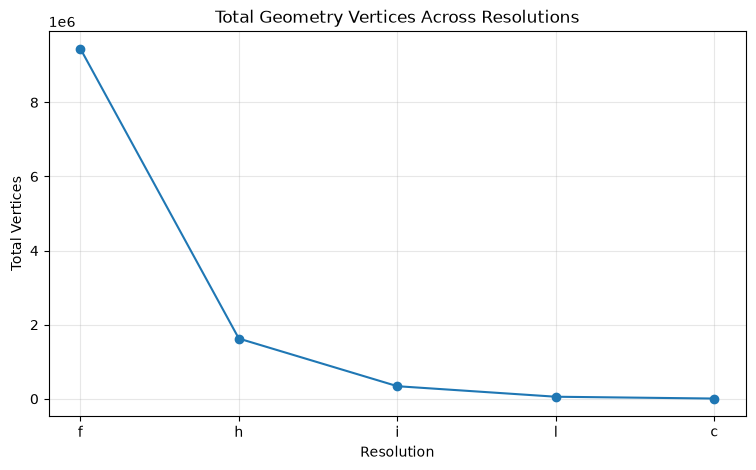

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["total_vertices"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Total Vertices")
plt.title("Total Geometry Vertices Across Resolutions")

plt.grid(True, alpha=0.3)
plt.show()

In [17]:
full_vertices = resolution_results["f"]["total_vertices"]

resolution_summary["vertex_retention_pct"] = (
    resolution_summary["total_vertices"]
    / full_vertices
    * 100
)

resolution_summary["vertex_reduction_pct"] = (
    100
    - resolution_summary["vertex_retention_pct"]
)

resolution_summary[
    [
        "resolution",
        "resolution_name",
        "total_vertices",
        "vertex_retention_pct",
        "vertex_reduction_pct"
    ]
]

,resolution,resolution_name,total_vertices,vertex_retention_pct,vertex_reduction_pct
0,f,Full,9453089,100.000000,0.000000
1,h,High,1626467,17.205667,82.794333
2,i,Intermediate,340359,3.600506,96.399494
3,l,Low,56351,0.596112,99.403888
4,c,Crude,7282,0.077033,99.922967


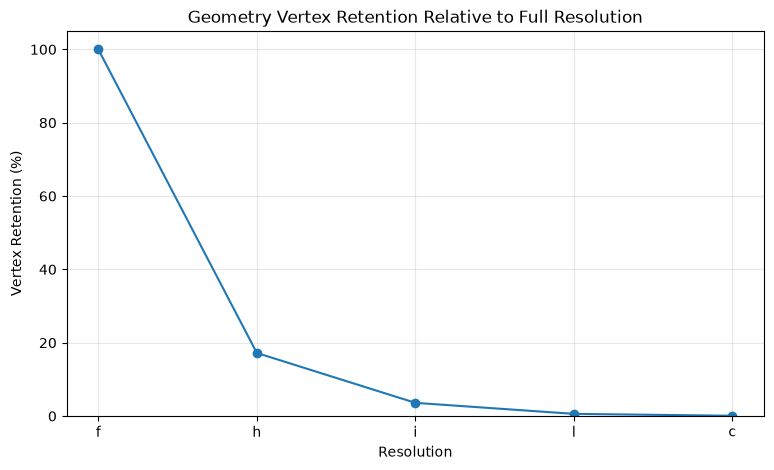

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["vertex_retention_pct"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Vertex Retention (%)")
plt.title("Geometry Vertex Retention Relative to Full Resolution")

plt.ylim(0, 105)
plt.grid(True, alpha=0.3)

plt.show()

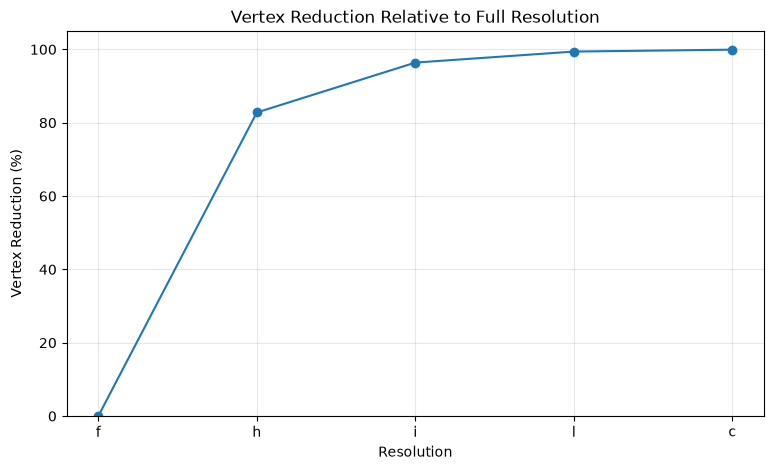

In [19]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["vertex_reduction_pct"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Vertex Reduction (%)")
plt.title("Vertex Reduction Relative to Full Resolution")

plt.ylim(0, 105)
plt.grid(True, alpha=0.3)

plt.show()

In [20]:
resolution_summary[
    [
        "resolution",
        "resolution_name",
        "mean_vertices",
        "median_vertices",
        "p95_vertices",
        "p99_vertices",
        "max_vertices"
    ]
]

,resolution,resolution_name,mean_vertices,median_vertices,p95_vertices,p99_vertices,max_vertices
0,f,Full,52.564761,10.0,69.00,324.00,1160926
1,h,High,11.236465,4.0,14.00,56.00,139786
2,i,Intermediate,10.367316,4.0,13.00,47.00,34332
3,l,Low,9.875745,4.0,12.00,55.00,6733
4,c,Crude,9.814016,4.0,15.95,85.62,1004


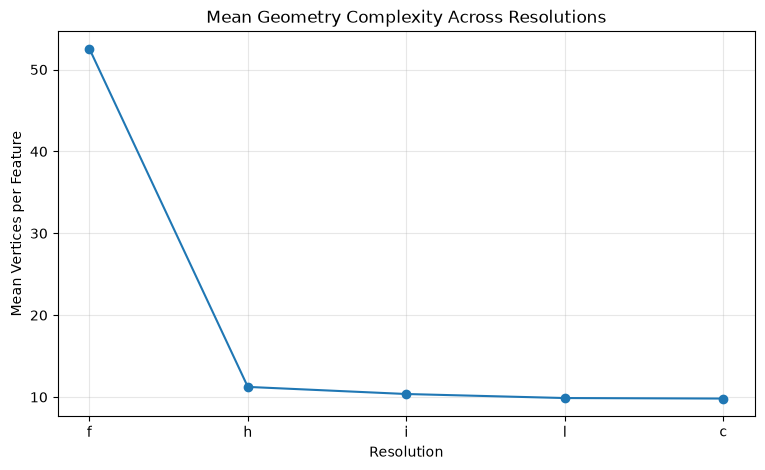

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["mean_vertices"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Mean Vertices per Feature")
plt.title("Mean Geometry Complexity Across Resolutions")

plt.grid(True, alpha=0.3)
plt.show()

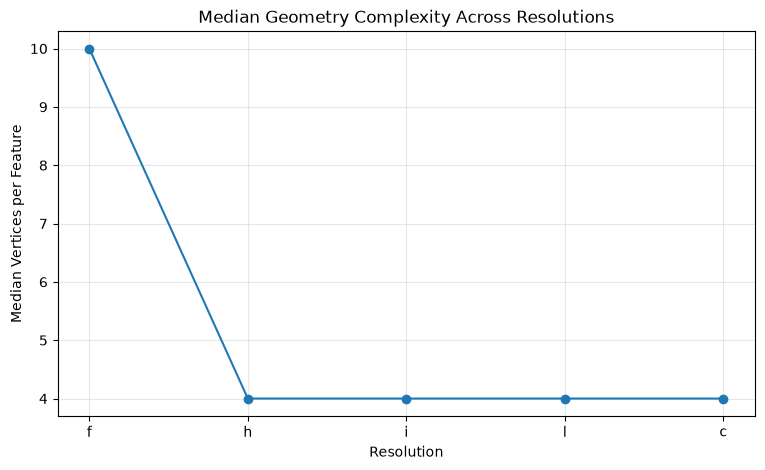

In [22]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["median_vertices"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Median Vertices per Feature")
plt.title("Median Geometry Complexity Across Resolutions")

plt.grid(True, alpha=0.3)
plt.show()

In [23]:
resolution_summary[
    [
        "resolution",
        "p95_vertices",
        "p99_vertices",
        "max_vertices"
    ]
]

,resolution,p95_vertices,p99_vertices,max_vertices
0,f,69.00,324.00,1160926
1,h,14.00,56.00,139786
2,i,13.00,47.00,34332
3,l,12.00,55.00,6733
4,c,15.95,85.62,1004


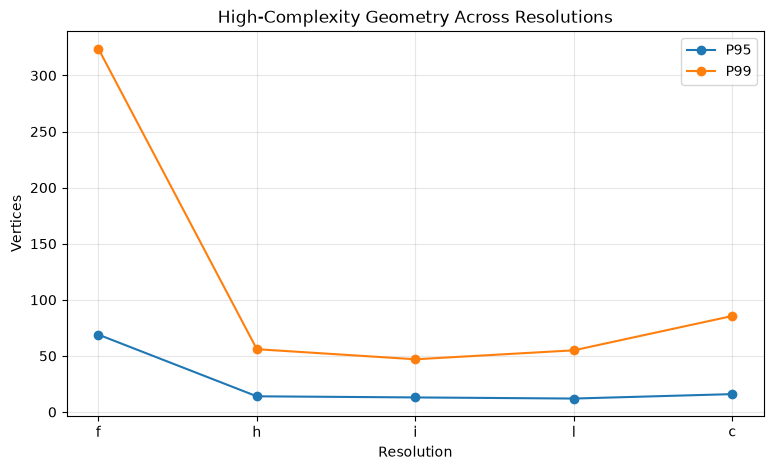

In [24]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["p95_vertices"],
    marker="o",
    label="P95"
)

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["p99_vertices"],
    marker="o",
    label="P99"
)

plt.xlabel("Resolution")
plt.ylabel("Vertices")
plt.title("High-Complexity Geometry Across Resolutions")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

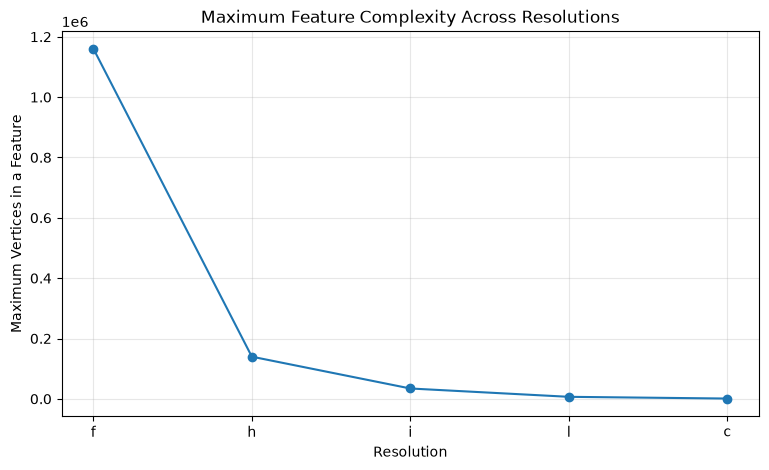

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["max_vertices"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Maximum Vertices in a Feature")
plt.title("Maximum Feature Complexity Across Resolutions")

plt.grid(True, alpha=0.3)
plt.show()

In [26]:
resolution_summary[
    [
        "resolution",
        "resolution_name",
        "shp_bytes",
        "shx_bytes",
        "dbf_bytes",
        "prj_bytes",
        "total_file_bytes"
    ]
]

,resolution,resolution_name,shp_bytes,shx_bytes,dbf_bytes,prj_bytes,total_file_bytes
0,f,Full,161320396,1438796,38125670,143,200885005
1,h,High,34129516,1158092,30687014,143,65974765
2,i,Intermediate,7284324,262740,6960186,143,14507393
3,l,Low,1221252,45748,1209898,143,2477041
4,c,Crude,158164,6036,157530,143,321873


In [27]:
resolution_summary["total_file_mb"] = (
    resolution_summary["total_file_bytes"]
    / (1024 ** 2)
)

resolution_summary[
    [
        "resolution",
        "resolution_name",
        "total_file_mb"
    ]
]

,resolution,resolution_name,total_file_mb
0,f,Full,191.578870
1,h,High,62.918439
2,i,Intermediate,13.835328
3,l,Low,2.362290
4,c,Crude,0.306962


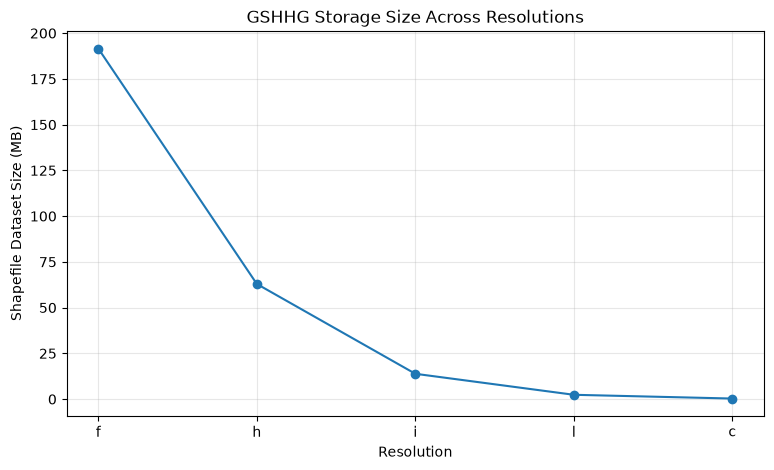

In [28]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["total_file_mb"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Shapefile Dataset Size (MB)")
plt.title("GSHHG Storage Size Across Resolutions")

plt.grid(True, alpha=0.3)
plt.show()

In [29]:
resolution_summary["total_wkb_mb"] = (
    resolution_summary["total_wkb_bytes"]
    / (1024 ** 2)
)

resolution_summary[
    [
        "resolution",
        "resolution_name",
        "total_wkb_mb",
        "mean_wkb_bytes"
    ]
]

,resolution,resolution_name,total_wkb_mb,mean_wkb_bytes
0,f,Full,146.472268,854.036183
1,h,High,26.612481,192.783432
2,i,Intermediate,5.600485,178.877064
3,l,Low,0.930590,171.011917
4,c,Crude,0.120314,170.024259


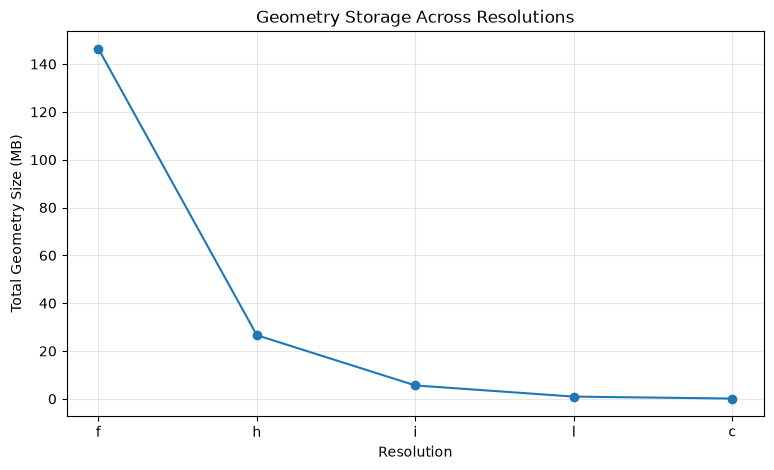

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["total_wkb_mb"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Total Geometry Size (MB)")
plt.title("Geometry Storage Across Resolutions")

plt.grid(True, alpha=0.3)
plt.show()

In [31]:
full_wkb = resolution_results["f"]["total_wkb_bytes"]

resolution_summary["wkb_retention_pct"] = (
    resolution_summary["total_wkb_bytes"]
    / full_wkb
    * 100
)

resolution_summary["wkb_reduction_pct"] = (
    100
    - resolution_summary["wkb_retention_pct"]
)

resolution_summary[
    [
        "resolution",
        "resolution_name",
        "wkb_retention_pct",
        "wkb_reduction_pct"
    ]
]

,resolution,resolution_name,wkb_retention_pct,wkb_reduction_pct
0,f,Full,100.000000,0.000000
1,h,High,18.168955,81.831045
2,i,Intermediate,3.823580,96.176420
3,l,Low,0.635335,99.364665
4,c,Crude,0.082141,99.917859


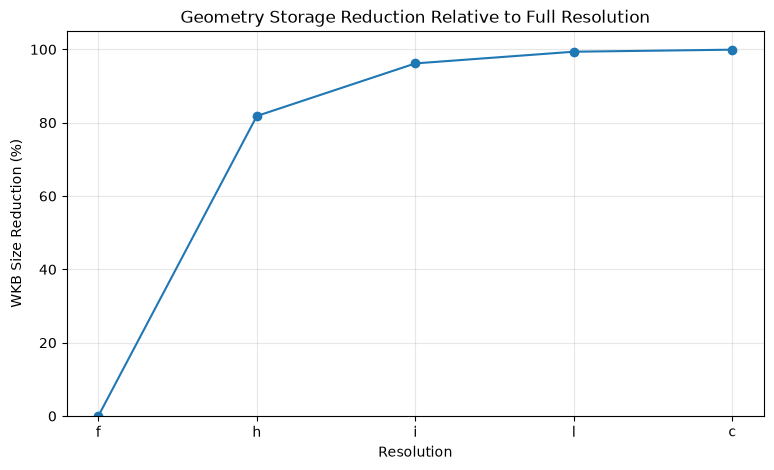

In [32]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["wkb_reduction_pct"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("WKB Size Reduction (%)")
plt.title("Geometry Storage Reduction Relative to Full Resolution")

plt.ylim(0, 105)
plt.grid(True, alpha=0.3)

plt.show()

In [33]:
resolution_summary[
    [
        "resolution",
        "resolution_name",
        "total_polygon_parts"
    ]
]

,resolution,resolution_name,total_polygon_parts
0,f,Full,179837
1,h,High,144749
2,i,Intermediate,32830
3,l,Low,5706
4,c,Crude,742


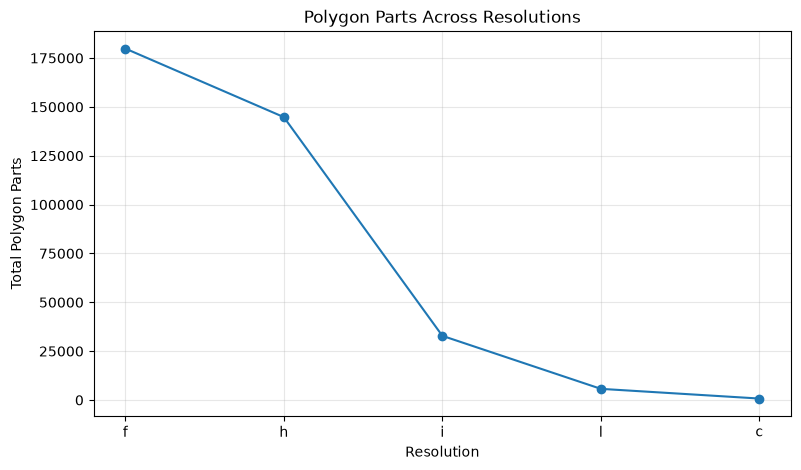

In [34]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["total_polygon_parts"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Total Polygon Parts")
plt.title("Polygon Parts Across Resolutions")

plt.grid(True, alpha=0.3)
plt.show()

In [35]:
resolution_summary[
    [
        "resolution",
        "resolution_name",
        "total_holes"
    ]
]

,resolution,resolution_name,total_holes
0,f,Full,0
1,h,High,0
2,i,Intermediate,0
3,l,Low,0
4,c,Crude,0


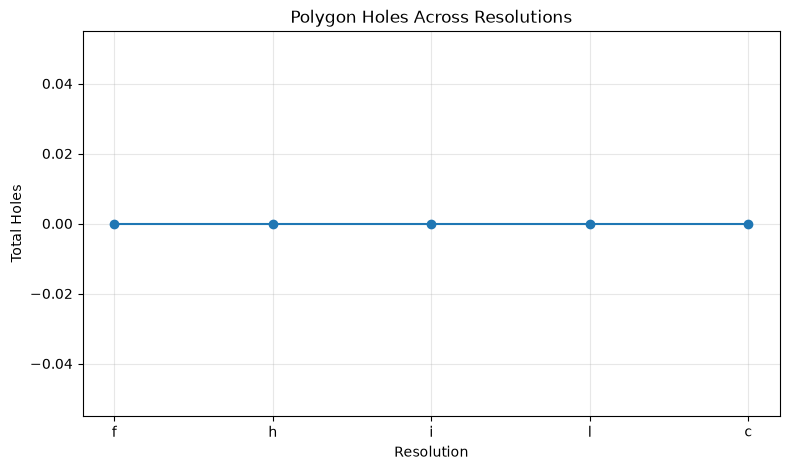

In [36]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["total_holes"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Total Holes")
plt.title("Polygon Holes Across Resolutions")

plt.grid(True, alpha=0.3)
plt.show()

In [37]:
gdf_f = resolution_results["f"]["data"]

[
    column
    for column in gdf_f.columns
    if "area" in column.lower()
]

['area']

In [38]:
area_results = []

for resolution in RESOLUTION_ORDER:
    data = resolution_results[resolution]["data"]

    result = {
        "resolution": resolution,
        "total_area_km2": data["area"].sum(),
        "mean_area_km2": data["area"].mean(),
        "median_area_km2": data["area"].median(),
    }

    area_results.append(result)

area_summary = pd.DataFrame(area_results)

area_summary

,resolution,total_area_km2,mean_area_km2,median_area_km2
0,f,1.856958e+08,1032.578648,0.092677
1,h,1.856949e+08,1282.875204,0.132634
2,i,1.856785e+08,5655.758015,1.562313
3,l,1.856136e+08,32529.540924,29.241135
4,c,1.853437e+08,249789.287321,641.613248


In [39]:
full_area = area_summary.loc[
    area_summary["resolution"] == "f",
    "total_area_km2"
].iloc[0]

area_summary["area_retention_pct"] = (
    area_summary["total_area_km2"]
    / full_area
    * 100
)

area_summary["area_difference_pct"] = (
    area_summary["area_retention_pct"] - 100
)

area_summary

,resolution,total_area_km2,mean_area_km2,median_area_km2,area_retention_pct,area_difference_pct
0,f,1.856958e+08,1032.578648,0.092677,100.000000,0.000000
1,h,1.856949e+08,1282.875204,0.132634,99.999492,-0.000508
2,i,1.856785e+08,5655.758015,1.562313,99.990678,-0.009322
3,l,1.856136e+08,32529.540924,29.241135,99.955688,-0.044312
4,c,1.853437e+08,249789.287321,641.613248,99.810338,-0.189662


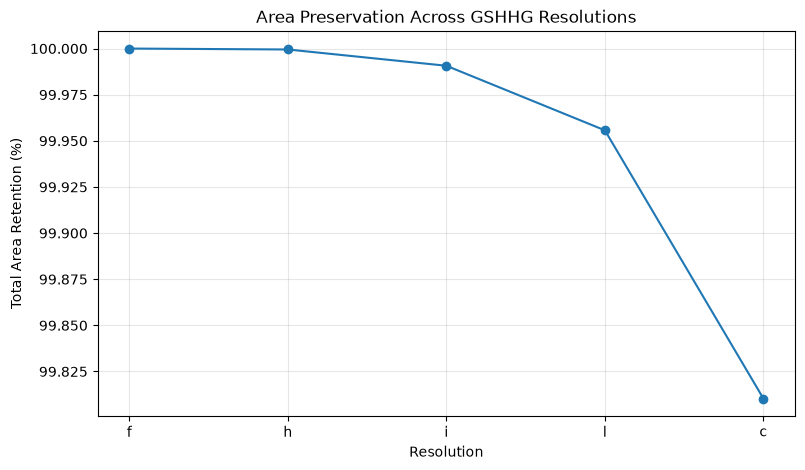

In [40]:
plt.figure(figsize=(9, 5))

plt.plot(
    area_summary["resolution"],
    area_summary["area_retention_pct"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Total Area Retention (%)")
plt.title("Area Preservation Across GSHHG Resolutions")

plt.grid(True, alpha=0.3)

plt.show()

In [41]:
id_sets = {}

for resolution in RESOLUTION_ORDER:
    data = resolution_results[resolution]["data"]

    id_sets[resolution] = set(data["id"])

for resolution in RESOLUTION_ORDER:
    print(
        resolution.upper(),
        len(id_sets[resolution])
    )

F 179837
H 144749
I 32830
L 5706
C 742


In [42]:
full_ids = id_sets["f"]

id_comparison = []

for resolution in RESOLUTION_ORDER:
    current_ids = id_sets[resolution]

    common_ids = full_ids & current_ids
    missing_ids = full_ids - current_ids
    extra_ids = current_ids - full_ids

    id_comparison.append({
        "resolution": resolution,
        "common_with_full": len(common_ids),
        "missing_from_resolution": len(missing_ids),
        "extra_ids": len(extra_ids),
    })

id_comparison = pd.DataFrame(id_comparison)

id_comparison

,resolution,common_with_full,missing_from_resolution,extra_ids
0,f,179837,0,0
1,h,144278,35559,471
2,i,32414,147423,416
3,l,5572,174265,134
4,c,684,179153,58


In [43]:
feature_tables = {}

for resolution in RESOLUTION_ORDER:
    data = resolution_results[resolution]["data"]

    feature_tables[resolution] = (
        data[
            [
                "id",
                "vertex_count",
                "polygon_parts",
                "hole_count",
                "area"
            ]
        ]
        .copy()
        .rename(columns={
            "vertex_count": f"vertices_{resolution}",
            "polygon_parts": f"parts_{resolution}",
            "hole_count": f"holes_{resolution}",
            "area": f"area_{resolution}",
        })
    )

In [44]:
feature_comparison = feature_tables["f"]

for resolution in RESOLUTION_ORDER[1:]:
    feature_comparison = feature_comparison.merge(
        feature_tables[resolution],
        on="id",
        how="inner"
    )

feature_comparison.shape

(683, 21)

In [45]:
feature_comparison.head()

,id,vertices_f,parts_f,holes_f,area_f,vertices_h,parts_h,holes_h,area_h,vertices_i,...,holes_i,area_i,vertices_l,parts_l,holes_l,area_l,vertices_c,parts_c,holes_c,area_c
0,0-E,1160926,1,0,5.065405e+07,139786,1,0,5.065405e+07,34332,...,0,5.065405e+07,6733,1,0,5.065405e+07,1004,1,0,5.065405e+07
1,0-W,20177,1,0,5.065405e+07,1922,1,0,5.065405e+07,503,...,0,5.065405e+07,121,1,0,5.065405e+07,27,1,0,5.065405e+07
2,1,257365,1,0,2.922097e+07,28032,1,0,2.922097e+07,6675,...,0,2.922097e+07,1290,1,0,2.922097e+07,221,1,0,2.922097e+07
3,2,876536,1,0,2.015474e+07,111436,1,0,2.015474e+07,25378,...,0,2.015474e+07,4570,1,0,2.015474e+07,667,1,0,2.015474e+07
4,3,338141,1,0,1.753416e+07,40118,1,0,1.753416e+07,9904,...,0,1.753416e+07,1964,1,0,1.753416e+07,311,1,0,1.753416e+07


In [46]:
for resolution in RESOLUTION_ORDER[1:]:
    feature_comparison[
        f"vertex_retention_{resolution}_pct"
    ] = (
        feature_comparison[f"vertices_{resolution}"]
        / feature_comparison["vertices_f"]
        * 100
    )

feature_comparison[
    [
        "id",
        "vertices_f",
        "vertices_h",
        "vertices_i",
        "vertices_l",
        "vertices_c",
        "vertex_retention_h_pct",
        "vertex_retention_i_pct",
        "vertex_retention_l_pct",
        "vertex_retention_c_pct",
    ]
].head()

,id,vertices_f,vertices_h,vertices_i,vertices_l,vertices_c,vertex_retention_h_pct,vertex_retention_i_pct,vertex_retention_l_pct,vertex_retention_c_pct
0,0-E,1160926,139786,34332,6733,1004,12.040905,2.957294,0.579968,0.086483
1,0-W,20177,1922,503,121,27,9.525698,2.492938,0.599693,0.133816
2,1,257365,28032,6675,1290,221,10.891924,2.593593,0.501234,0.085870
3,2,876536,111436,25378,4570,667,12.713226,2.895260,0.521370,0.076095
4,3,338141,40118,9904,1964,311,11.864281,2.928956,0.580823,0.091973


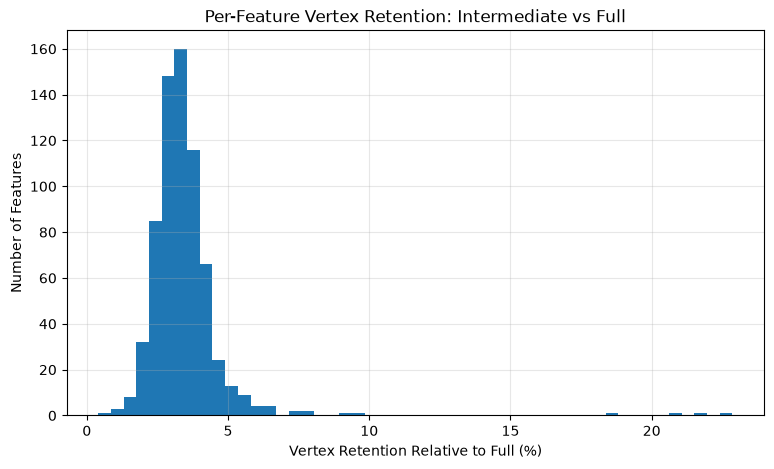

In [47]:
plt.figure(figsize=(9, 5))

plt.hist(
    feature_comparison["vertex_retention_i_pct"].dropna(),
    bins=50
)

plt.xlabel("Vertex Retention Relative to Full (%)")
plt.ylabel("Number of Features")
plt.title("Per-Feature Vertex Retention: Intermediate vs Full")

plt.grid(True, alpha=0.3)

plt.show()

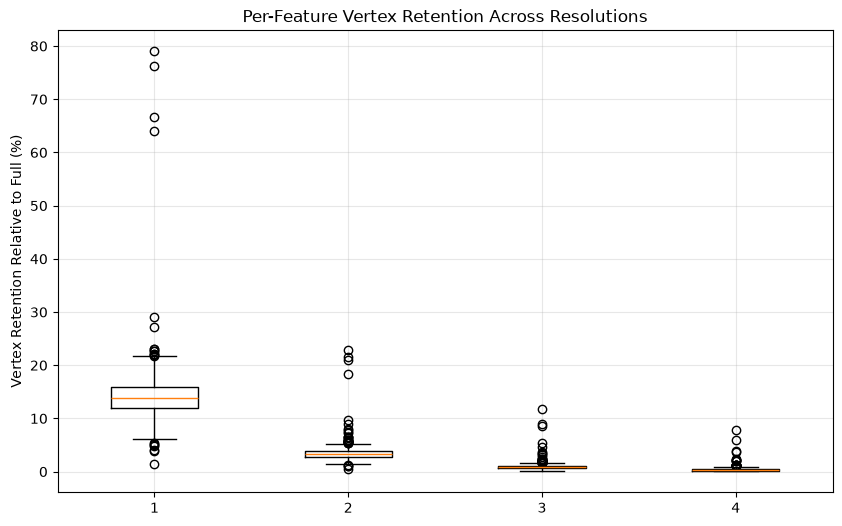

In [48]:
retention_columns = [
    "vertex_retention_h_pct",
    "vertex_retention_i_pct",
    "vertex_retention_l_pct",
    "vertex_retention_c_pct",
]

retention_data = [
    feature_comparison[column].dropna()
    for column in retention_columns
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    retention_data,
    label=["High", "Intermediate", "Low", "Crude"]
)

plt.ylabel("Vertex Retention Relative to Full (%)")
plt.title("Per-Feature Vertex Retention Across Resolutions")

plt.grid(True, alpha=0.3)

plt.show()

In [49]:
feature_comparison[
    [
        "id",
        "vertices_f",
        "vertices_h",
        "vertices_i",
        "vertices_l",
        "vertices_c",
        "vertex_retention_i_pct",
    ]
].sort_values(
    "vertex_retention_i_pct"
).head(20)

,id,vertices_f,vertices_h,vertices_i,vertices_l,vertices_c,vertex_retention_i_pct
569,637,5643,80,23,6,4,0.407585
568,636,1660,65,17,5,4,1.024096
473,535,1274,52,14,6,4,1.098901
131,138,9276,482,113,15,6,1.218197
77,81,3551,360,53,18,5,1.492537
675,755,2027,213,31,10,4,1.529354
180,194,3628,198,58,17,6,1.598677
357,402,1187,130,19,7,4,1.600674
256,286,1917,119,32,8,5,1.669275
661,739,833,68,14,6,4,1.680672


In [50]:
feature_comparison[
    [
        "id",
        "vertices_f",
        "vertices_i",
        "vertex_retention_i_pct",
    ]
].sort_values(
    "vertices_i",
    ascending=False
).head(20)

,id,vertices_f,vertices_i,vertex_retention_i_pct
0,0-E,1160926,34332,2.957294
3,2,876536,25378,2.895260
4,3,338141,9904,2.928956
6,7,231861,7279,3.139381
5,6,213065,6844,3.212165
2,1,257365,6675,2.593593
10,11,162827,4765,2.926419
7,8,76370,2529,3.311510
20,21,64098,1808,2.820681
8,9,52567,1659,3.155972


In [51]:
for resolution in RESOLUTION_ORDER[1:]:
    feature_comparison[
        f"area_retention_{resolution}_pct"
    ] = (
        feature_comparison[f"area_{resolution}"]
        / feature_comparison["area_f"]
        * 100
    )

In [52]:
feature_comparison[
    [
        "id",
        "area_f",
        "area_h",
        "area_i",
        "area_l",
        "area_c",
        "area_retention_i_pct",
    ]
].head(20)

,id,area_f,area_h,area_i,area_l,area_c,area_retention_i_pct
0,0-E,5.065405e+07,5.065405e+07,5.065405e+07,5.065405e+07,5.065405e+07,100.0
1,0-W,5.065405e+07,5.065405e+07,5.065405e+07,5.065405e+07,5.065405e+07,100.0
2,1,2.922097e+07,2.922097e+07,2.922097e+07,2.922097e+07,2.922097e+07,100.0
3,2,2.015474e+07,2.015474e+07,2.015474e+07,2.015474e+07,2.015474e+07,100.0
4,3,1.753416e+07,1.753416e+07,1.753416e+07,1.753416e+07,1.753416e+07,100.0
5,6,7.592692e+06,7.592692e+06,7.592692e+06,7.592692e+06,7.592692e+06,100.0
6,7,2.113828e+06,2.113828e+06,2.113828e+06,2.113828e+06,2.113828e+06,100.0
7,8,7.800249e+05,7.800249e+05,7.800249e+05,7.800249e+05,7.800249e+05,100.0
8,9,7.325867e+05,7.325867e+05,7.325867e+05,7.325867e+05,7.325867e+05,100.0
9,10,5.907297e+05,5.907297e+05,5.907297e+05,5.907297e+05,5.907297e+05,100.0


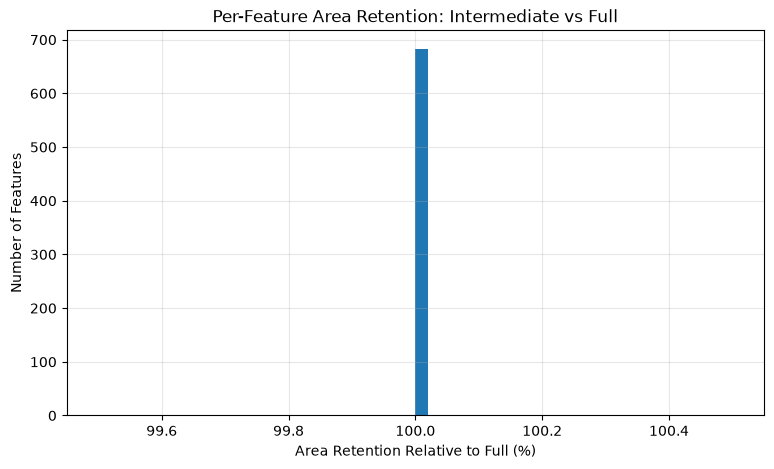

In [53]:
plt.figure(figsize=(9, 5))

plt.hist(
    feature_comparison["area_retention_i_pct"].dropna(),
    bins=50
)

plt.xlabel("Area Retention Relative to Full (%)")
plt.ylabel("Number of Features")
plt.title("Per-Feature Area Retention: Intermediate vs Full")

plt.grid(True, alpha=0.3)

plt.show()

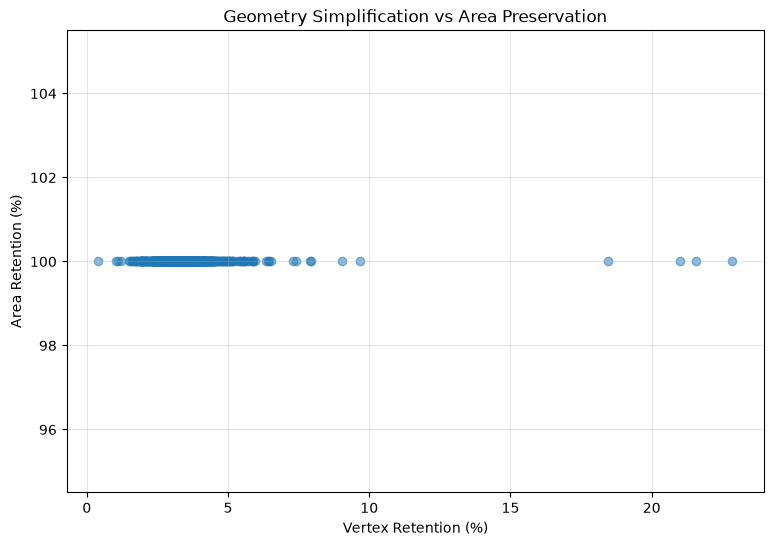

In [54]:
plt.figure(figsize=(9, 6))

plt.scatter(
    feature_comparison["vertex_retention_i_pct"],
    feature_comparison["area_retention_i_pct"],
    alpha=0.5
)

plt.xlabel("Vertex Retention (%)")
plt.ylabel("Area Retention (%)")
plt.title("Geometry Simplification vs Area Preservation")

plt.grid(True, alpha=0.3)

plt.show()

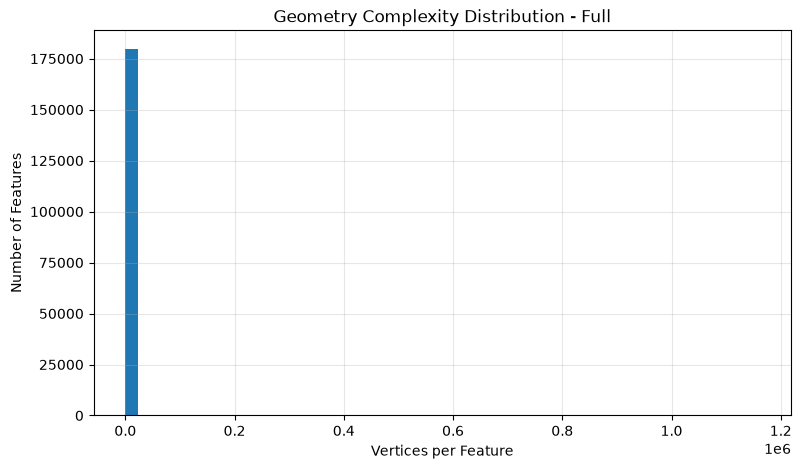

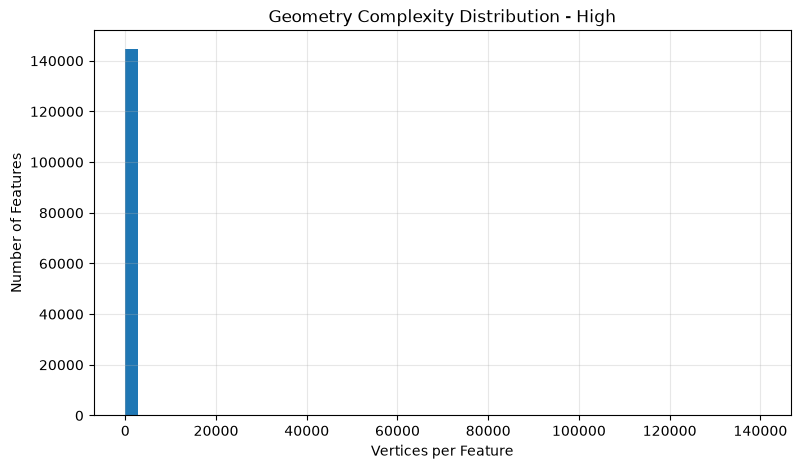

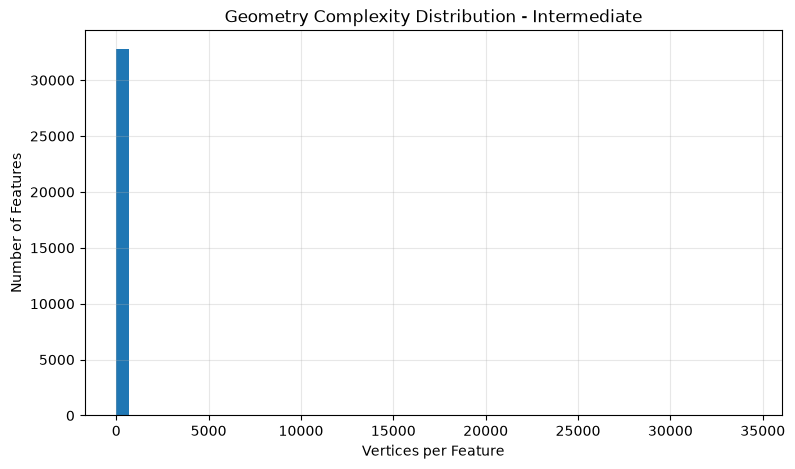

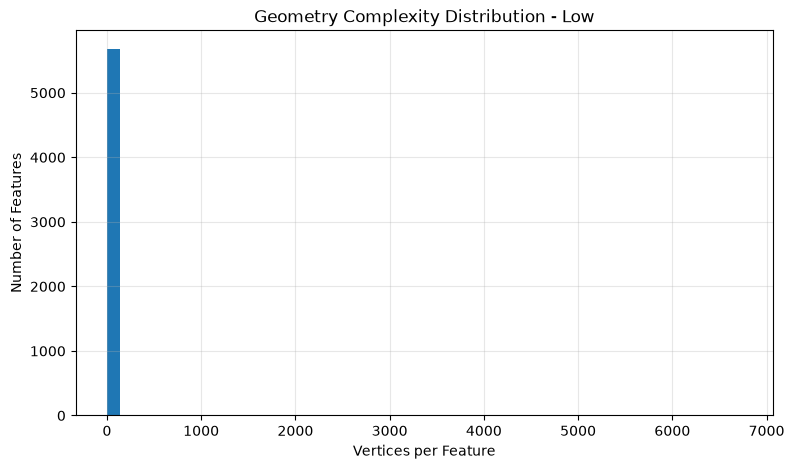

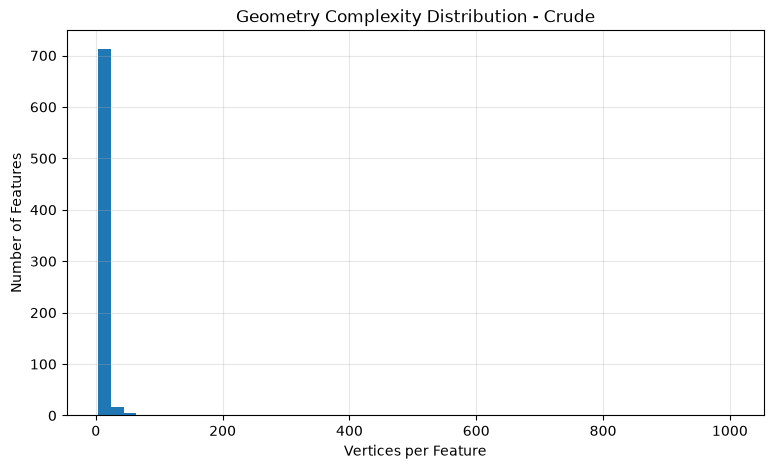

In [55]:
for resolution in RESOLUTION_ORDER:

    data = resolution_results[resolution]["data"]

    plt.figure(figsize=(9, 5))

    plt.hist(
        data["vertex_count"],
        bins=50
    )

    plt.xlabel("Vertices per Feature")
    plt.ylabel("Number of Features")
    plt.title(
        f"Geometry Complexity Distribution - "
        f"{RESOLUTION_INFO[resolution]['name']}"
    )

    plt.grid(True, alpha=0.3)

    plt.show()

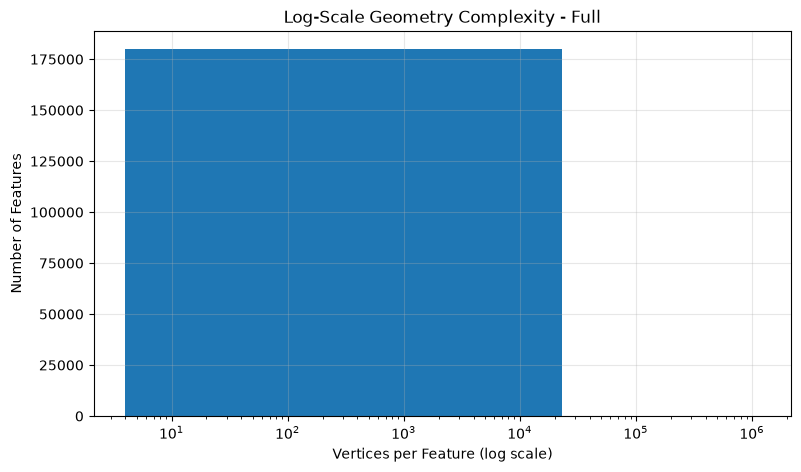

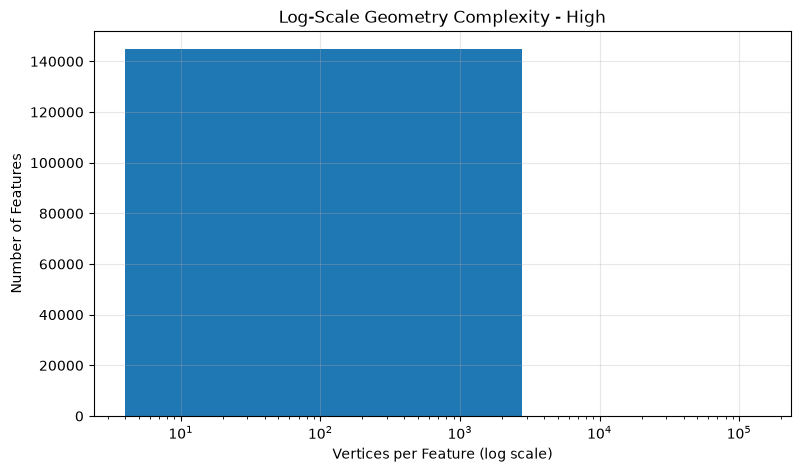

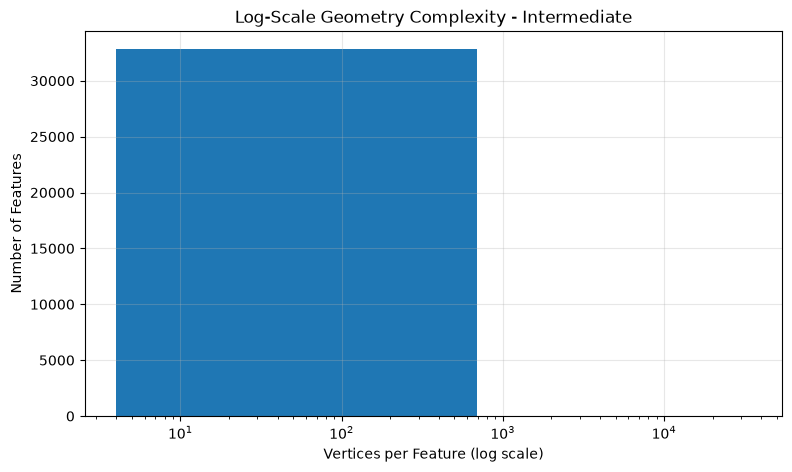

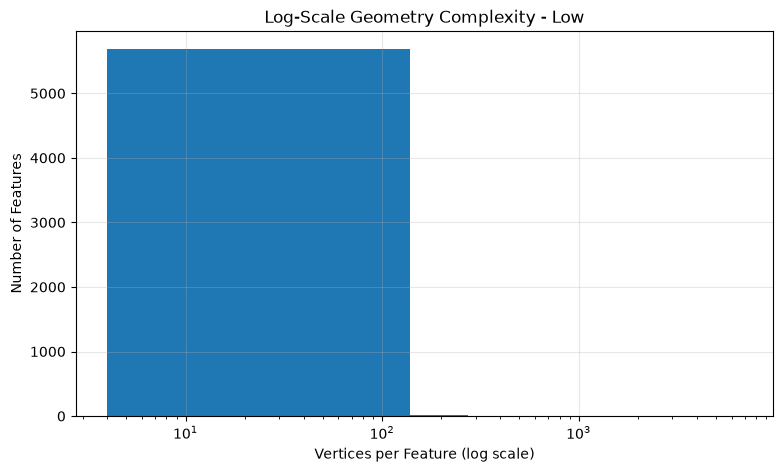

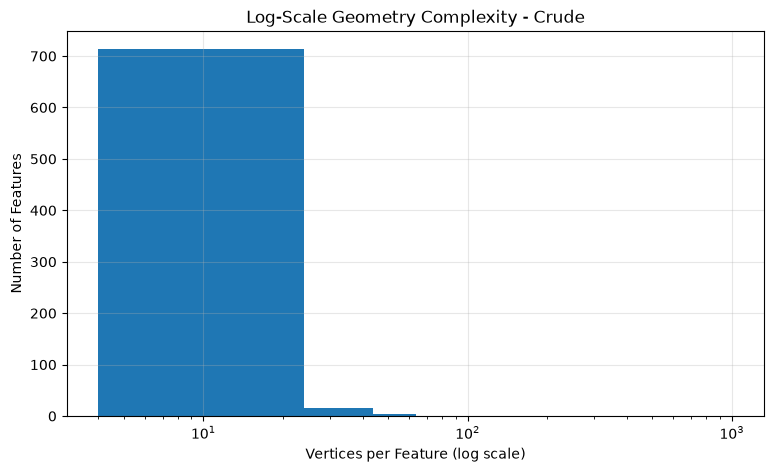

In [56]:
for resolution in RESOLUTION_ORDER:

    data = resolution_results[resolution]["data"]

    values = data["vertex_count"]
    values = values[values > 0]

    plt.figure(figsize=(9, 5))

    plt.hist(
        values,
        bins=50
    )

    plt.xscale("log")

    plt.xlabel("Vertices per Feature (log scale)")
    plt.ylabel("Number of Features")
    plt.title(
        f"Log-Scale Geometry Complexity - "
        f"{RESOLUTION_INFO[resolution]['name']}"
    )

    plt.grid(True, alpha=0.3)

    plt.show()

In [57]:
def complexity_concentration(data, percentages=(1, 5, 10, 25, 50)):
    values = (
        data["vertex_count"]
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    total = values.sum()

    results = []

    for percentage in percentages:
        n = max(
            1,
            int(np.ceil(len(values) * percentage / 100))
        )

        contribution = (
            values.iloc[:n].sum()
            / total
            * 100
        )

        results.append({
            "top_features_pct": percentage,
            "vertex_contribution_pct": contribution
        })

    return pd.DataFrame(results)

In [58]:
intermediate_data = resolution_results["i"]["data"]

complexity_concentration(intermediate_data)

,top_features_pct,vertex_contribution_pct
0,1,46.806754
1,5,55.482006
2,10,60.419733
3,25,69.531289
4,50,80.708605


In [59]:
concentration_results = []

for resolution in RESOLUTION_ORDER:

    data = resolution_results[resolution]["data"]

    concentration = complexity_concentration(data)

    concentration["resolution"] = resolution

    concentration_results.append(concentration)

complexity_concentration_summary = pd.concat(
    concentration_results,
    ignore_index=True
)

complexity_concentration_summary

,top_features_pct,vertex_contribution_pct,resolution
0,1,64.970921,f
1,5,75.265588,f
2,10,79.898275,f
3,25,86.459463,f
4,50,92.273150,f
5,1,47.954370,h
6,5,56.953138,h
7,10,61.853453,h
8,25,70.819943,h
9,50,82.200930,h


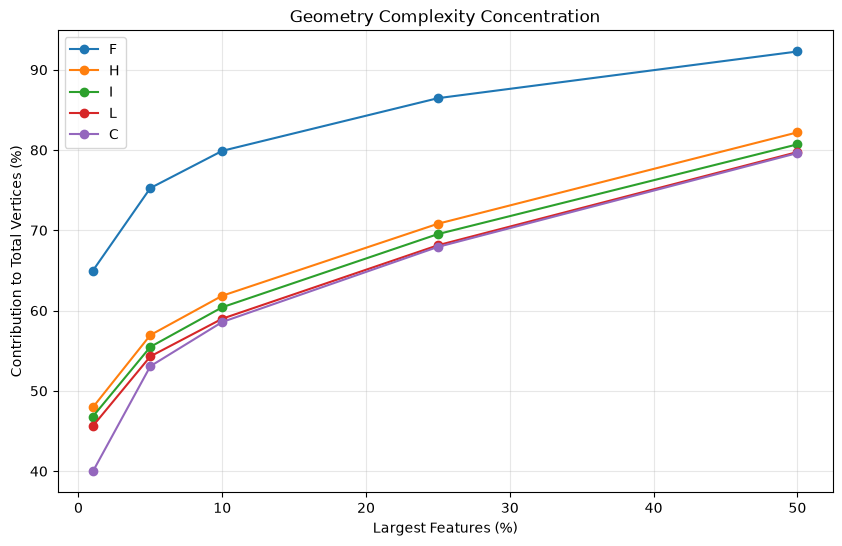

In [60]:
plt.figure(figsize=(10, 6))

for resolution in RESOLUTION_ORDER:

    subset = complexity_concentration_summary[
        complexity_concentration_summary["resolution"] == resolution
    ]

    plt.plot(
        subset["top_features_pct"],
        subset["vertex_contribution_pct"],
        marker="o",
        label=resolution.upper()
    )

plt.xlabel("Largest Features (%)")
plt.ylabel("Contribution to Total Vertices (%)")
plt.title("Geometry Complexity Concentration")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [61]:
resolution_summary["vertices_per_mb"] = (
    resolution_summary["total_vertices"]
    / resolution_summary["total_file_mb"]
)

resolution_summary[
    [
        "resolution",
        "resolution_name",
        "vertices_per_mb"
    ]
]

,resolution,resolution_name,vertices_per_mb
0,f,Full,49343.066951
1,h,High,25850.402968
2,i,Intermediate,24600.717633
3,l,Low,23854.391662
4,c,Crude,23722.805057


In [62]:
resolution_summary["vertices_per_feature"] = (
    resolution_summary["total_vertices"]
    / resolution_summary["features"]
)

resolution_summary[
    [
        "resolution",
        "resolution_name",
        "features",
        "vertices_per_feature"
    ]
]

,resolution,resolution_name,features,vertices_per_feature
0,f,Full,179837,52.564761
1,h,High,144749,11.236465
2,i,Intermediate,32830,10.367316
3,l,Low,5706,9.875745
4,c,Crude,742,9.814016


In [63]:
final_resolution_report = resolution_summary[
    [
        "resolution",
        "resolution_name",
        "features",

        "total_vertices",
        "mean_vertices",
        "median_vertices",
        "p95_vertices",
        "p99_vertices",
        "max_vertices",

        "vertex_retention_pct",
        "vertex_reduction_pct",

        "total_polygon_parts",
        "total_holes",

        "total_wkb_mb",
        "wkb_retention_pct",
        "wkb_reduction_pct",

        "total_file_mb",

        "load_time_seconds",
    ]
].copy()

final_resolution_report

,resolution,resolution_name,features,total_vertices,mean_vertices,median_vertices,p95_vertices,p99_vertices,max_vertices,vertex_retention_pct,vertex_reduction_pct,total_polygon_parts,total_holes,total_wkb_mb,wkb_retention_pct,wkb_reduction_pct,total_file_mb,load_time_seconds
0,f,Full,179837,9453089,52.564761,10.0,69.00,324.00,1160926,100.000000,0.000000,179837,0,146.472268,100.000000,0.000000,191.578870,1.800290
1,h,High,144749,1626467,11.236465,4.0,14.00,56.00,139786,17.205667,82.794333,144749,0,26.612481,18.168955,81.831045,62.918439,1.173266
2,i,Intermediate,32830,340359,10.367316,4.0,13.00,47.00,34332,3.600506,96.399494,32830,0,5.600485,3.823580,96.176420,13.835328,0.276576
3,l,Low,5706,56351,9.875745,4.0,12.00,55.00,6733,0.596112,99.403888,5706,0,0.930590,0.635335,99.364665,2.362290,0.048504
4,c,Crude,742,7282,9.814016,4.0,15.95,85.62,1004,0.077033,99.922967,742,0,0.120314,0.082141,99.917859,0.306962,0.007874


In [64]:
display(
    final_resolution_report.style
    .format({
        "mean_vertices": "{:,.1f}",
        "median_vertices": "{:,.1f}",
        "p95_vertices": "{:,.1f}",
        "p99_vertices": "{:,.1f}",
        "vertex_retention_pct": "{:.2f}%",
        "vertex_reduction_pct": "{:.2f}%",
        "wkb_retention_pct": "{:.2f}%",
        "wkb_reduction_pct": "{:.2f}%",
        "total_wkb_mb": "{:,.2f}",
        "total_file_mb": "{:,.2f}",
        "load_time_seconds": "{:.2f}",
    })
)

,resolution,resolution_name,features,total_vertices,mean_vertices,median_vertices,p95_vertices,p99_vertices,max_vertices,vertex_retention_pct,vertex_reduction_pct,total_polygon_parts,total_holes,total_wkb_mb,wkb_retention_pct,wkb_reduction_pct,total_file_mb,load_time_seconds
0,f,Full,179837,9453089,52.6,10.0,69.0,324.0,1160926,100.00%,0.00%,179837,0,146.47,100.00%,0.00%,191.58,1.80
1,h,High,144749,1626467,11.2,4.0,14.0,56.0,139786,17.21%,82.79%,144749,0,26.61,18.17%,81.83%,62.92,1.17
2,i,Intermediate,32830,340359,10.4,4.0,13.0,47.0,34332,3.60%,96.40%,32830,0,5.60,3.82%,96.18%,13.84,0.28
3,l,Low,5706,56351,9.9,4.0,12.0,55.0,6733,0.60%,99.40%,5706,0,0.93,0.64%,99.36%,2.36,0.05
4,c,Crude,742,7282,9.8,4.0,15.9,85.6,1004,0.08%,99.92%,742,0,0.12,0.08%,99.92%,0.31,0.01


In [65]:
resolution_comparison = resolution_summary[
    [
        "resolution",
        "resolution_name",
        "features",
        "total_vertices",
        "vertex_reduction_pct",
        "total_wkb_mb",
        "wkb_reduction_pct",
        "total_file_mb",
    ]
].copy()

resolution_comparison

,resolution,resolution_name,features,total_vertices,vertex_reduction_pct,total_wkb_mb,wkb_reduction_pct,total_file_mb
0,f,Full,179837,9453089,0.000000,146.472268,0.000000,191.578870
1,h,High,144749,1626467,82.794333,26.612481,81.831045,62.918439
2,i,Intermediate,32830,340359,96.399494,5.600485,96.176420,13.835328
3,l,Low,5706,56351,99.403888,0.930590,99.364665,2.362290
4,c,Crude,742,7282,99.922967,0.120314,99.917859,0.306962


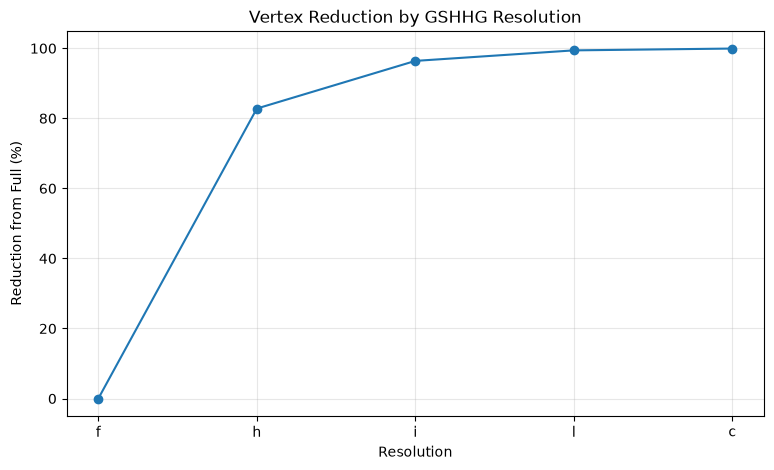

In [66]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["vertex_reduction_pct"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Reduction from Full (%)")
plt.title("Vertex Reduction by GSHHG Resolution")

plt.grid(True, alpha=0.3)
plt.show()

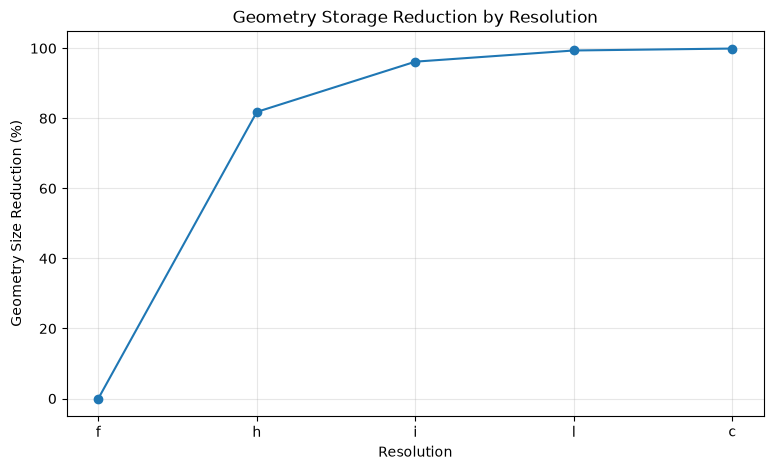

In [67]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["wkb_reduction_pct"],
    marker="o"
)

plt.xlabel("Resolution")
plt.ylabel("Geometry Size Reduction (%)")
plt.title("Geometry Storage Reduction by Resolution")

plt.grid(True, alpha=0.3)
plt.show()

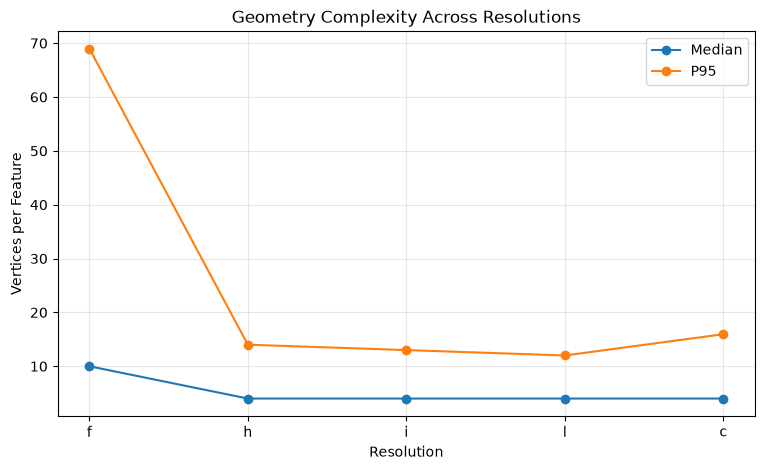

In [68]:
plt.figure(figsize=(9, 5))

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["median_vertices"],
    marker="o",
    label="Median"
)

plt.plot(
    resolution_summary["resolution"],
    resolution_summary["p95_vertices"],
    marker="o",
    label="P95"
)

plt.xlabel("Resolution")
plt.ylabel("Vertices per Feature")
plt.title("Geometry Complexity Across Resolutions")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()